Dieser Code trainiert und evaluiert ein BERT-Modell anhand dieses Datensatzes:

@inproceedings{tonneau-etal-2024-languages,

    title = "From Languages to Geographies: Towards Evaluating Cultural Bias in Hate Speech Datasets",

    author = {Tonneau, Manuel  and
      Liu, Diyi  and
      Fraiberger, Samuel  and
      Schroeder, Ralph  and
      Hale, Scott  and
      Röttger, Paul},
    editor = {Chung, Yi-Ling  and
      Talat, Zeerak  and
      Nozza, Debora  and
      Plaza-del-Arco, Flor Miriam  and
      Röttger, Paul  and
      Mostafazadeh Davani, Aida  and
      Calabrese, Agostina},
    
    booktitle = "Proceedings of the 8th Workshop on Online Abuse and Harms (WOAH 2024)",
    month = jun,
    year = "2024",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2024.woah-1.23",
    pages = "283--311",
    abstract = "Perceptions of hate can vary greatly across cultural contexts.
    Hate speech (HS) datasets, however, have traditionally been developed by
    language. This hides potential cultural biases, as one language may be
    spoken in different countries home to different cultures. In this work, we
    evaluate cultural bias in HS datasets by leveraging two interrelated
    cultural proxies: language and geography. We conduct a systematic survey
    of HS datasets in eight languages and confirm past findings on their
    English-language bias, but also show that this bias has been steadily
    decreasing in the past few years. For three geographically-widespread
    languages{---}English, Arabic and Spanish{---}we then leverage
    geographical metadata from tweets to approximate geo-cultural contexts by
    pairing language and country information. We find that HS datasets for
    these languages exhibit a strong geo-cultural bias, largely
    overrepresenting a handful of countries (e.g., US and UK for English)
    relative to their prominence in both the broader social media population
    and the general population speaking these languages. Based on these
    findings, we formulate recommendations for the creation of future HS
    datasets.",}


In [ ]:
!pip uninstall -y transformers
!pip uninstall -y sentence-transformers
!pip uninstall -y fasttransform


Found existing installation: transformers 5.16.1
Uninstalling transformers-5.16.1:
  Successfully uninstalled transformers-5.16.1
Found existing installation: sentence-transformers 5.7.0
Uninstalling sentence-transformers-5.7.0:
  Successfully uninstalled sentence-transformers-5.7.0
Found existing installation: fasttransform 0.0.2
Uninstalling fasttransform-0.0.2:
  Successfully uninstalled fasttransform-0.0.2


In [ ]:
!pip uninstall -y transformers


In [ ]:
!pip install transformers==5.16.1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
import sklearn.metrics as metrics

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset

import transformers

from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

print(transformers.__version__)
print(transformers.__file__)

5.16.1
/usr/local/lib/python3.13/dist-packages/transformers/__init__.py


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Daten initialiseren**

In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/de_hf_112024.csv",sep=",",engine="python",on_bad_lines="skip",encoding="utf-8")
df.head()


,text,labels,source,dataset,nb_annotators
0,gleich an die wand stellen und erschiessen..,1.0,Facebook,Bretschneider,2.0
1,nicht dass ich der Grundbotschaft dieses Post'...,0.0,Facebook,Bretschneider,2.0
2,"Das mit dem ""an die Wand stellen und erschiessen""",0.0,Facebook,Bretschneider,2.0
3,"Seit dem ""an die Wand stellen und erschiessen""...",0.0,Facebook,Bretschneider,2.0
4,Ja ja die Kriminelle Heimatpartei FPÖ von Kind...,0.0,Facebook,Bretschneider,2.0


In [4]:
df=df.dropna(subset=["labels"])

**Daten splitten**

In [5]:
from sklearn.model_selection import train_test_split
X=df["text"]
y=df["labels"].astype(int)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=42,stratify=y_train)

In [7]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

**Tokenizer**

In [8]:
#Tokenizer Laden
model_standard="bert-base-german-cased"
tokenizer=AutoTokenizer.from_pretrained(model_standard)

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/255k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/485k [00:00<?, ?B/s]

In [9]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    max_length=128
)

In [12]:
class HateSpeechDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)
train_dataset = HateSpeechDataset(train_encodings, y_train)
val_dataset = HateSpeechDataset(val_encodings, y_val)
test_dataset= HateSpeechDataset(test_encodings, y_test)

**Modell**

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_standard,
    num_labels=2 #klassenanzahl
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  439MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-german-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [15]:
import inspect

print(inspect.signature(TrainingArguments))

(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_compile_

In [16]:
#from transformers import TrainingArguments

#Trainingsparameter
training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=50
)


In [17]:
#Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)
#Modell Training starten
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.223585,0.214468
2,0.170656,0.217305
3,0.113228,0.253954


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1707, training_loss=0.17588548961967912, metrics={'train_runtime': 2168.9868, 'train_samples_per_second': 83.887, 'train_steps_per_second': 1.312, 'total_flos': 6650062035349920.0, 'train_loss': 0.17588548961967912, 'epoch': 3.0})

**validierung**

In [23]:
pred_output = trainer.predict(val_dataset)
y_val_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_valpred = (y_val_proba > 0.5).astype(int)

In [24]:
with open("bert_validierung.txt", "w") as fd:
    for text, label, proba in zip(X_val, y_val, y_val_proba):
        fd.write(f"Text: {text}\n")
        fd.write(f"Label: {label}\n")
        fd.write(f"Wahrscheinlichkeit Hasskommentar: {proba}\n")
        fd.write("\n"*4)
schwellen = np.arange(0.0, 1.01, 0.01)
beste_schwelle = 0
beste_f1 = 0

for t in schwellen:
    y_pred_t = (y_val_proba > t).astype(int)
    f1 = metrics.f1_score(y_val, y_pred_t)
    if f1 > beste_f1:
        beste_f1 = f1
        beste_schwelle = t
        print("Schwelle: ", beste_schwelle)
        print("F1_score: ", beste_f1)
        print("\n"*4)

print("Beste Schwelle:", beste_schwelle)
print("Bester F1-Score:", beste_f1)

Schwelle:  0.0
F1_score:  0.22163588390501318





Schwelle:  0.01
F1_score:  0.3468248429867411





Schwelle:  0.02
F1_score:  0.4





Schwelle:  0.03
F1_score:  0.43735763097949887





Schwelle:  0.04
F1_score:  0.4628180039138943





Schwelle:  0.05
F1_score:  0.4823348694316436





Schwelle:  0.06
F1_score:  0.4986623863028357





Schwelle:  0.07
F1_score:  0.5158421345191774





Schwelle:  0.08
F1_score:  0.5305651672433679





Schwelle:  0.09
F1_score:  0.5403800475059383





Schwelle:  0.1
F1_score:  0.5504587155963303





Schwelle:  0.11
F1_score:  0.5590994371482176





Schwelle:  0.12
F1_score:  0.5685019206145967





Schwelle:  0.13
F1_score:  0.5718015665796344





Schwelle:  0.14
F1_score:  0.5748344370860927





Schwelle:  0.15
F1_score:  0.5804713804713805





Schwelle:  0.16
F1_score:  0.5839616175462645





Schwelle:  0.17
F1_score:  0.5880701754385965





Schwelle:  0.18
F1_score:  0.590421729807005





Schwelle:  0.19
F1_score:  0.6008771929824561



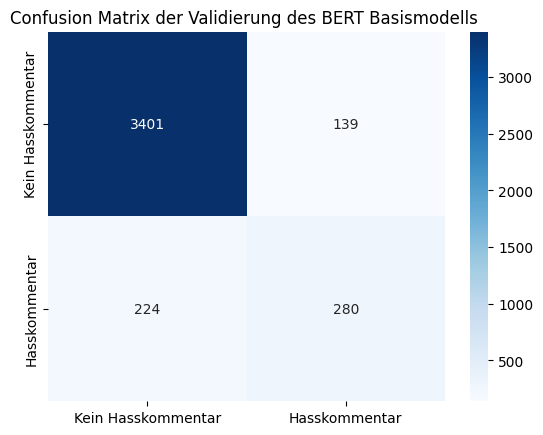

In [25]:
cm = metrics.confusion_matrix(y_val, y_valpred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar", "Hasskommentar"],
    yticklabels=["Kein Hasskommentar", "Hasskommentar"]
)
plt.title("Confusion Matrix der Validierung des BERT Basismodells ")
plt.show()

In [ ]:
# accuracy
vaccuracy = metrics.accuracy_score(y_val, y_valpred)
# precision
vprecision = metrics.precision_score(y_val, y_valpred)
# recall
vrecall = metrics.recall_score(y_val, y_valpred)
# f1-score
vf1=metrics.f1_score(y_val, y_valpred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_val, y_valpred).ravel()
vspecificity = tn/(tn+fp)
# macro recall
vmacro_recall=metrics.recall_score(y_val, y_valpred, average='macro')
# macro f1-score
vmacro_f1=metrics.f1_score(y_val, y_valpred, average='macro')

In [ ]:
print("Accuracy: ", vaccuracy)
print("Precision: ", vprecision)
print("Recall: ", vrecall)
print("Specificity: ", vspecificity)
print("F1-Score: ", vf1)
print("Macro Recall: ", vmacro_recall)
print("Macro F1-Score: ", vmacro_f1)

Accuracy:  0.9134520276953512
Precision:  0.6824644549763034
Recall:  0.5714285714285714
Specificity:  0.9621468926553672
F1-Score:  0.6220302375809935
Macro Recall:  0.7667877320419694
Macro F1-Score:  0.7865806032920326


In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_normal"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/Colab Notebooks/BERT_model_normal"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/BERT_model_normal/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/BERT_model_normal/tokenizer.json')

In [26]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > 0.5).astype(int)

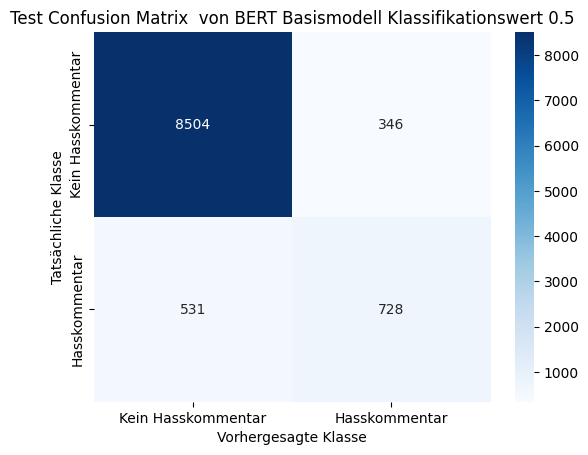

In [27]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title("Test Confusion Matrix  von BERT Basismodell Klassifikationswert 0.5")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.9140369967355821
Precision:  0.6731793960923623
Recall:  0.6020651310563939
Specificity:  0.9584180790960452
F1-Score:  0.6356394129979036
Macro Recall:  0.7802416050762195
Macro F1-Score:  0.793454765098178


In [ ]:
pred_output = trainer.predict(test_dataset)
y_test_proba = torch.softmax(torch.tensor(pred_output.predictions), dim=1)[:,1].numpy()
y_pred = (y_test_proba > beste_schwelle).astype(int)

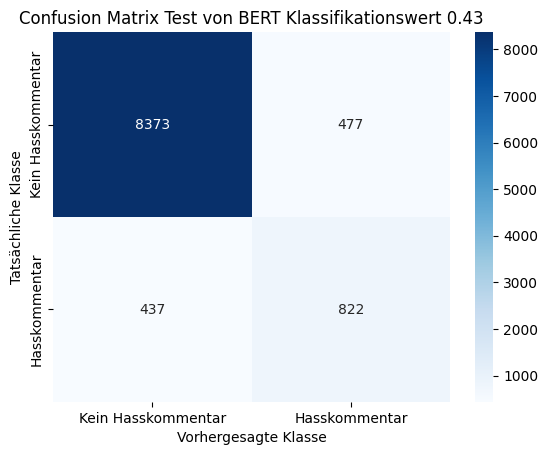

In [ ]:
# Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kein Hasskommentar","Hasskommentar"],
    yticklabels=["Kein Hasskommentar","Hasskommentar"]
)
plt.title(f"Test Confusion Matrix  von BERT Basismodell Klassifikationswert {beste_schwelle}")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

In [ ]:
# accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
# precision
precision = metrics.precision_score(y_test, y_pred)
# recall
recall = metrics.recall_score(y_test, y_pred)
# f1-score
f1=metrics.f1_score(y_test, y_pred)
# specificity
tn, fp, fn, tp = metrics.confusion_matrix(y_test, y_pred).ravel()
specificity = tn/(tn+fp)
# macro recall
macro_recall=metrics.recall_score(y_test, y_pred, average='macro')
# macro f1-score
macro_f1=metrics.f1_score(y_test, y_pred, average='macro')

In [ ]:
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("Specificity: ", specificity)
print("F1-Score: ", f1)
print("Macro Recall: ", macro_recall)
print("Macro F1-Score: ", macro_f1)

Accuracy:  0.9095855178553764
Precision:  0.6327944572748267
Recall:  0.6528991262907069
Specificity:  0.9461016949152542
F1-Score:  0.6426896012509773
Macro Recall:  0.7995004106029806
Macro F1-Score:  0.7954671109312644
